In [4]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import scipy as sp
import matplotlib.pyplot as plt

from mis_dro.plot import *
from mis_dro.experiments import ExperimentName

from mis_dro.results import preprocess_results_df, is_minimise_pareto_front, get_agg_df

from matplotlib import rc
rc('font', **{'family': 'serif', 'serif': ['Computer Modern'], "size":14})
rc('text', usetex=True)

In [3]:
experiment_name = ExperimentName.kl_newsvendor_1d
experiment_dir = Path(f"/Users/patrick/experiments/misdro/2025_01_21_paper_bas_experiments/{experiment_name.value}")
# experiment_dir = Path(f"/dcs/large/u1508153/misdro/2025_01_21_paper_bas_experiments/{experiment_name.value}")
all_results_df = pd.read_csv(experiment_dir / "results.csv", index_col=["uuid", "replication"])

wass_dir = Path("/Users/patrick/Experiments/misdro/2025_01_21_paper_bas_experiments/wasserstein_empirical")
wass_df = pd.read_csv(wass_dir / "results.csv", index_col=["uuid", "replication"])

all_results_df = pd.concat([all_results_df, wass_df])

In [12]:
filter_dgp = "truncated_normal"  # filter by DGP
results_df = preprocess_results_df(all_results_df, filter_dgp)
# results_df = preprocess_results_df(all_results_df, filter_dgp)
results_df.head(3)

solution  \
uuid                                 replication                         
905d2b22-d634-43bd-88ab-301e4c4544ad 0            [15.806229409672879]   
                                     1            [16.053047357969728]   
                                     2            [15.950415767039745]   

                                                  dgp_time  likelihood_time  \
uuid                                 replication                              
905d2b22-d634-43bd-88ab-301e4c4544ad 0            0.000791         0.000103   
                                     1            0.000669         0.000091   
                                     2            0.000615         0.000088   

                                                  posterior_time  solve_time  \
uuid                                 replication                               
905d2b22-d634-43bd-88ab-301e4c4544ad 0                  0.000056    0.040409   
                                     1                  0.000059    0.027276   
                                     2                  0.000055    0.030464   

                                                  setup_time  \
uuid                                 replication               
905d2b22-d634-43bd-88ab-301e4c4544ad 0                   NaN   
                                     1                   NaN   
                                     2                   NaN   

                                                  log_partition_constant  \
uuid                                 replication                           
905d2b22-d634-43bd-88ab-301e4c4544ad 0                               0.0   
                                     1                               0.0   
                                     2                               0.0   

                                                                                 out_of_sample_cost  \
uuid                                 replication                                                      
905d2b22-d634-43bd-88ab-301e4c4544ad 0            [44.59710870444056, 36.42214922132565, 0.86402...   
                                     1            [16.08116828746995, 26.181524779389363, 13.106...   
                                     2            [21.64174709524606, 11.129969030564544, 58.907...   

                                                 algorithm  contamination  \
uuid                                 replication                            
905d2b22-d634-43bd-88ab-301e4c4544ad 0               kl_pp            0.0   
                                     1               kl_pp            0.0   
                                     2               kl_pp            0.0   

                                                  ... num_observations  \
uuid                                 replication  ...                    
905d2b22-d634-43bd-88ab-301e4c4544ad 0            ...               20   
                                     1            ...               20   
                                     2            ...               20   

                                                 num_posterior_samples  \
uuid                                 replication                         
905d2b22-d634-43bd-88ab-301e4c4544ad 0                               1   
                                     1                               1   
                                     2                               1   

                                                  num_replications  \
uuid                                 replication                     
905d2b22-d634-43bd-88ab-301e4c4544ad 0                         500   
                                     1                         500   
                                     2                         500   

                                                  num_test_observations  \
uuid                                 replication                          
905d2b22-d634-43bd-88ab-301e4c4544ad 0         

In [13]:
# NOTE if you are visualising the 'num_observations' experiment, uncomment below line
# results_df = results_df.loc[(results_df["num_total_samples"] == 100) | (results_df["algorithm"] == "kl_empirical")]

In [14]:
agg_df = get_agg_df(results_df, ["algorithm", "dgp", "epsilon", "inference", "num_total_samples", "num_observations"])
agg_df

/Users/patrick/Projects/mis-dro-code/mis_dro/results.py:66: FutureWarning: The provided callable <function mean at 0x10c84f240> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  agg_df = gb.agg(
/Users/patrick/Projects/mis-dro-code/mis_dro/results.py:66: FutureWarning: The provided callable <function std at 0x10c84f380> is currently using SeriesGroupBy.std. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "std" instead.
  agg_df = gb.agg(


out_of_sample_mean  \
algorithm             dgp              epsilon inference num_total_samples num_observations                       
kl_bdro               truncated_normal 0.001   bayes     25                20                         33.183397   
                                                         100               20                         32.479560   
                                                         900               20                         32.238666   
                                       0.002   bayes     25                20                         33.162919   
                                                         100               20                         32.491418   
...                                                                                                         ...   
wasserstein_empirical truncated_normal 40.000  empirical 20                20                         75.390153   
                                       45.000  empirical 20                20                         82.957073   
                                       50.000  empirical 20                20                         90.570659   
                                       55.000  empirical 20                20                         98.207473   
                                       60.000  empirical 20                20                        105.856616   

                                                                                             out_of_sample_var  \
algorithm             dgp              epsilon inference num_total_samples num_observations                      
kl_bdro               truncated_normal 0.001   bayes     25                20                       690.722569   
                                                         100               20                       655.081832   
                                                         900               20                       641.350995   
                                       0.002   bayes     25                20                       691.583013   
                                                         100               20                       653.271270   
...                                                                                                        ...   
wasserstein_empirical truncated_normal 40.000  empirical 20                20                       623.895475   
                                       45.000  empirical 20                20                       633.343603   
                                       50.000  empirical 20                20                       638.614344   
                                       55.000  empirical 20                20                       641.306879   
                                       60.000  empirical 20                20                       642.192663   

                                                                                             sum_of_in_group_var  \
algorithm             dgp              epsilon inference num_total_samples num_observations                        
kl_bdro               truncated_normal 0.001   bayes     25                20                         663.527418   
                                                         100               20                         635.906347   
                                                         900               20                         625.535744   
                                       0.002   bayes     25                20                         664.586005   
                                                         100               20                         634.143757   
...                                                                                                          ...   
wasserstein_empirical truncated_normal 40.000  empirical 20                20                         541.210741   
                                       45.000  empirical 20           

## Plot mean-variance trade-off

For each DGP, we plot the out-of-sample mean $\hat{\mu}_M(\epsilon)$ and variance $\hat{\sigma}_M(\epsilon)$ of Bayesian DRO with different posteriors.

All BDRO points are Pareto dominated for M = 25 ? True
All BDRO points are Pareto dominated for M = 100 ? True
All BDRO points are Pareto dominated for M = 900 ? False


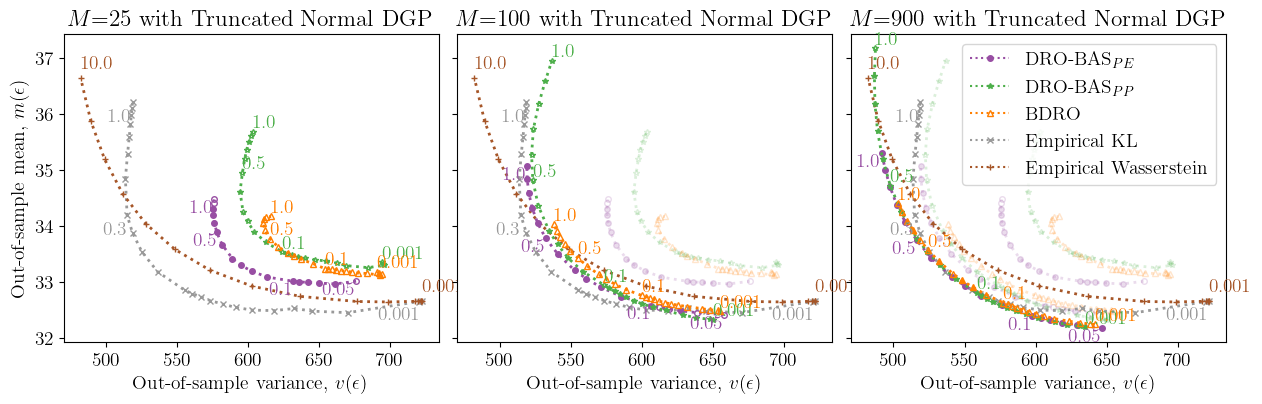

In [15]:
total_samples_list = agg_df.loc[~(agg_df.index.get_level_values("algorithm").isin(("kl_empirical", "wasserstein_empirical")))].index.get_level_values("num_total_samples").unique().tolist()
# num_observations_list = agg_df.index.get_level_values("num_observations").unique().tolist()
dgp_list = agg_df.index.get_level_values("dgp").unique().tolist()

nrows = len(dgp_list)
ncols = len(total_samples_list)
# ncols = len(num_observations_list)
trim_epsilon = 1.0
wass_trim_epsilon = 10.0

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, sharex=True, sharey=True, figsize=(5*ncols, nrows*4))
fig.subplots_adjust(wspace=0.05)
pd.options.mode.chained_assignment = None  # default='warn'
for i, dgp in enumerate(dgp_list):
    for j, total_samples in enumerate(total_samples_list):
    # for j, num_observations in enumerate(num_observations_list):

        # NOTE empirical KL doesn't sample, so we plot it before filtering by total_samples
        mean_variance_plot(axes[j], agg_df.loc["kl_empirical", dgp, :trim_epsilon, "empirical", :, :], **algorithm_inference_style("kl_empirical", "empirical", label_inference=False), special_epsilons=[0.3], offset=0.1)
        # mean_variance_plot(axes[j], agg_df.loc["kl_empirical", dgp, :trim_epsilon, "empirical", num_observations, :], **algorithm_inference_style("kl_empirical", "empirical", label_inference=False), special_epsilons=[0.3], offset=0.1)
        mean_variance_plot(axes[j], agg_df.loc["wasserstein_empirical", dgp, :wass_trim_epsilon, "empirical", :, :], **algorithm_inference_style("wasserstein_empirical", "empirical", label_inference=False), special_epsilons=[0.3], offset=0.1)


        # filter by the total samples and DGP
        axis_df = agg_df.loc[:, dgp, :, :, total_samples, :]
        # axis_df = agg_df.loc[:, dgp, :, :, :, num_observations]
        axis_df.loc[:, "is_pareto_front"] = is_minimise_pareto_front(axis_df["out_of_sample_var"].values, axis_df["out_of_sample_mean"].values)
        for algorithm, inference in set(zip(axis_df.index.get_level_values("algorithm"), axis_df.index.get_level_values("inference"))):
            df = axis_df.loc[algorithm, :trim_epsilon, :, :]

            if algorithm == "kl_bdro":
                print("All BDRO points are Pareto dominated for M =", total_samples, "?", not df["is_pareto_front"].any())


            for k in range(j, len(total_samples_list)):
            # for k in range(j, len(num_observations_list)):
                alpha = 1.0
                is_labelled=True
                if j != k:
                    alpha = 0.2
                    is_labelled = False
                mean_variance_plot(axes[k], df, **algorithm_inference_style(algorithm, inference, label_inference=False), offset=0.0, is_labelled=is_labelled, alpha=alpha)
        if j == 0:
            axes[j].set_ylabel("Out-of-sample mean, $m(\epsilon)$")
        if j == 2:
            handles, labels = axes[j].get_legend_handles_labels()
            # algorithm_order = [AlgorithmName.kl_dro_bas.value, AlgorithmName.kl_pp.value, AlgorithmName.kl_bdro.value]
            algorithm_order = [AlgorithmName.kl_dro_bas.value, AlgorithmName.kl_pp.value, AlgorithmName.kl_bdro.value, AlgorithmName.kl_empirical.value, AlgorithmName.wasserstein_empirical.value]
            order = [list(labels).index(a) for a in algorithm_order]
            axes[j].legend([handles[idx] for idx in order],[labels[idx] for idx in order])
        axes[j].set_title("$M$" + f"={total_samples} with {NiceNameDGP[filter_dgp]}")
        # axes[j].set_title("$n$" + f"={num_observations} with {NiceNameDGP[filter_dgp]}")
        axes[j].set_xlabel("Out-of-sample variance, $v(\epsilon)$")

# fig.savefig(f"/Users/patrick/Experiments/misdro/2025_01_21_paper_bas_experiments/{experiment_name}_{filter_dgp}_empirical.pdf", bbox_inches="tight")
fig.savefig(f"/Users/patrick/Experiments/misdro/2025_01_21_paper_bas_experiments/{experiment_name}_{filter_dgp}_empirical_wasserstein.pdf", bbox_inches="tight")

## Solve & sampling time

In [7]:
solve_time_df = get_agg_df(results_df, ["algorithm", "dgp", "num_total_samples"])[["mean_solve_time", "std_solve_time", "mean_sample_time", "std_sample_time"]]

decimal_places = 3
format_string = "{:.3f}"
solve_time_df["str_solve_time"] = solve_time_df[["mean_solve_time", "std_solve_time"]].apply(
    lambda x: format_string.format(np.round(x["mean_solve_time"], decimal_places)) + " (" + format_string.format(np.round(x["std_solve_time"], decimal_places)) + ")", axis=1
)
solve_time_df["str_sample_time"] = solve_time_df[["mean_sample_time", "std_sample_time"]].apply(
    lambda x: format_string.format(np.round(1000 * x["mean_sample_time"], decimal_places)) + " (" + format_string.format(np.round(1000 * x["std_sample_time"], decimal_places)) + ")", axis=1
)
# solve_time_df.reindex(pd.MultiIndex.from_product(np.repeat(["kl_dro_bas", "kl_pp", "kl_bdro", "kl_empirical"], 3), solve_time_df.index.get_level_values("num_total_samples"), names=['algorithm', 'num_total_samples']))
# solve_time_df = solve_time_df.reindex(["kl_dro_bas", "kl_pp", "kl_bdro", "kl_empirical"])
# solve_time_df.index = solve_time_df.index.map(lambda x: AlgorithmName[x].value)
print(solve_time_df[["str_solve_time", "str_sample_time"]].unstack(level="algorithm").reindex(columns=pd.MultiIndex.from_product([["str_solve_time", "str_sample_time"], ["kl_dro_bas", "kl_pp", "kl_bdro"]])).to_latex())

\begin{tabular}{llllllll}
\toprule
 &  & \multicolumn{3}{r}{str_solve_time} & \multicolumn{3}{r}{str_sample_time} \\
 &  & kl_dro_bas & kl_pp & kl_bdro & kl_dro_bas & kl_pp & kl_bdro \\
dgp & num_total_samples &  &  &  &  &  &  \\
\midrule
\multirow[t]{4}{*}{exponential} & 20 & NaN & NaN & NaN & NaN & NaN & NaN \\
 & 25 & 0.024 (0.003) & 0.024 (0.003) & 0.068 (0.012) & 0.097 (0.007) & 0.117 (0.009) & 0.360 (0.018) \\
 & 100 & 0.036 (0.003) & 0.037 (0.003) & 0.148 (0.020) & 0.099 (0.007) & 0.122 (0.015) & 0.614 (0.045) \\
 & 900 & 0.422 (0.030) & 0.428 (0.032) & 0.724 (0.040) & 0.114 (0.010) & 0.155 (0.013) & 1.611 (0.117) \\
\cline{1-8}
\bottomrule
\end{tabular}



/dcs/pg20/u1508153/projects/mis-dro-code/mis_dro/plot.py:219: FutureWarning: The provided callable <function mean at 0x7fa0d8329940> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  agg_df = gb.agg(
/dcs/pg20/u1508153/projects/mis-dro-code/mis_dro/plot.py:219: FutureWarning: The provided callable <function std at 0x7fa0d8329a80> is currently using SeriesGroupBy.std. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "std" instead.
  agg_df = gb.agg(


# Plot sum of in-group variance and variance of in-group mean
Let $m$ be the number of test observations.
Let $k$ be the number of replications.
Let $\xi_{ij}$ be the $i^{\text{th}}$ test observation for replication $j$.
For a given replication $j$, the in-group mean and variance is
$$\mu_j = \frac{1}{m}\sum_{i=1}^m f(x_j, \xi_{ij}), \hspace{2em} v_j = \frac{1}{m-1}\sum_{i=1}^m \left( f(x_j, \xi_{ij}) - \mu_j \right)^2$$

We define the mean across all replications and all test observations as
$$\bar{\mu} = \frac{1}{mk} \sum_{j=1}^k \sum_{i=1}^m f(x_j, \xi_{ij}).$$

The total variance is defined by $$\frac{1}{mk-1}\sum_{j=1}^k \sum_{i=1}^m \left( f(x_j, \xi_{ij}) - \bar{\mu} \right)^2.$$
This can be decomposed into two terms.
The first is a constant times the sum of the in-group variances:
$$\frac{m-1}{km - 1} \sum^k_{j=1} v_j,$$
and the second term is a constant times the variance of the in-group means:
$$\frac{m(k-1)}{km - 1} \text{Var}(\mu_j).$$


KeyError: 25

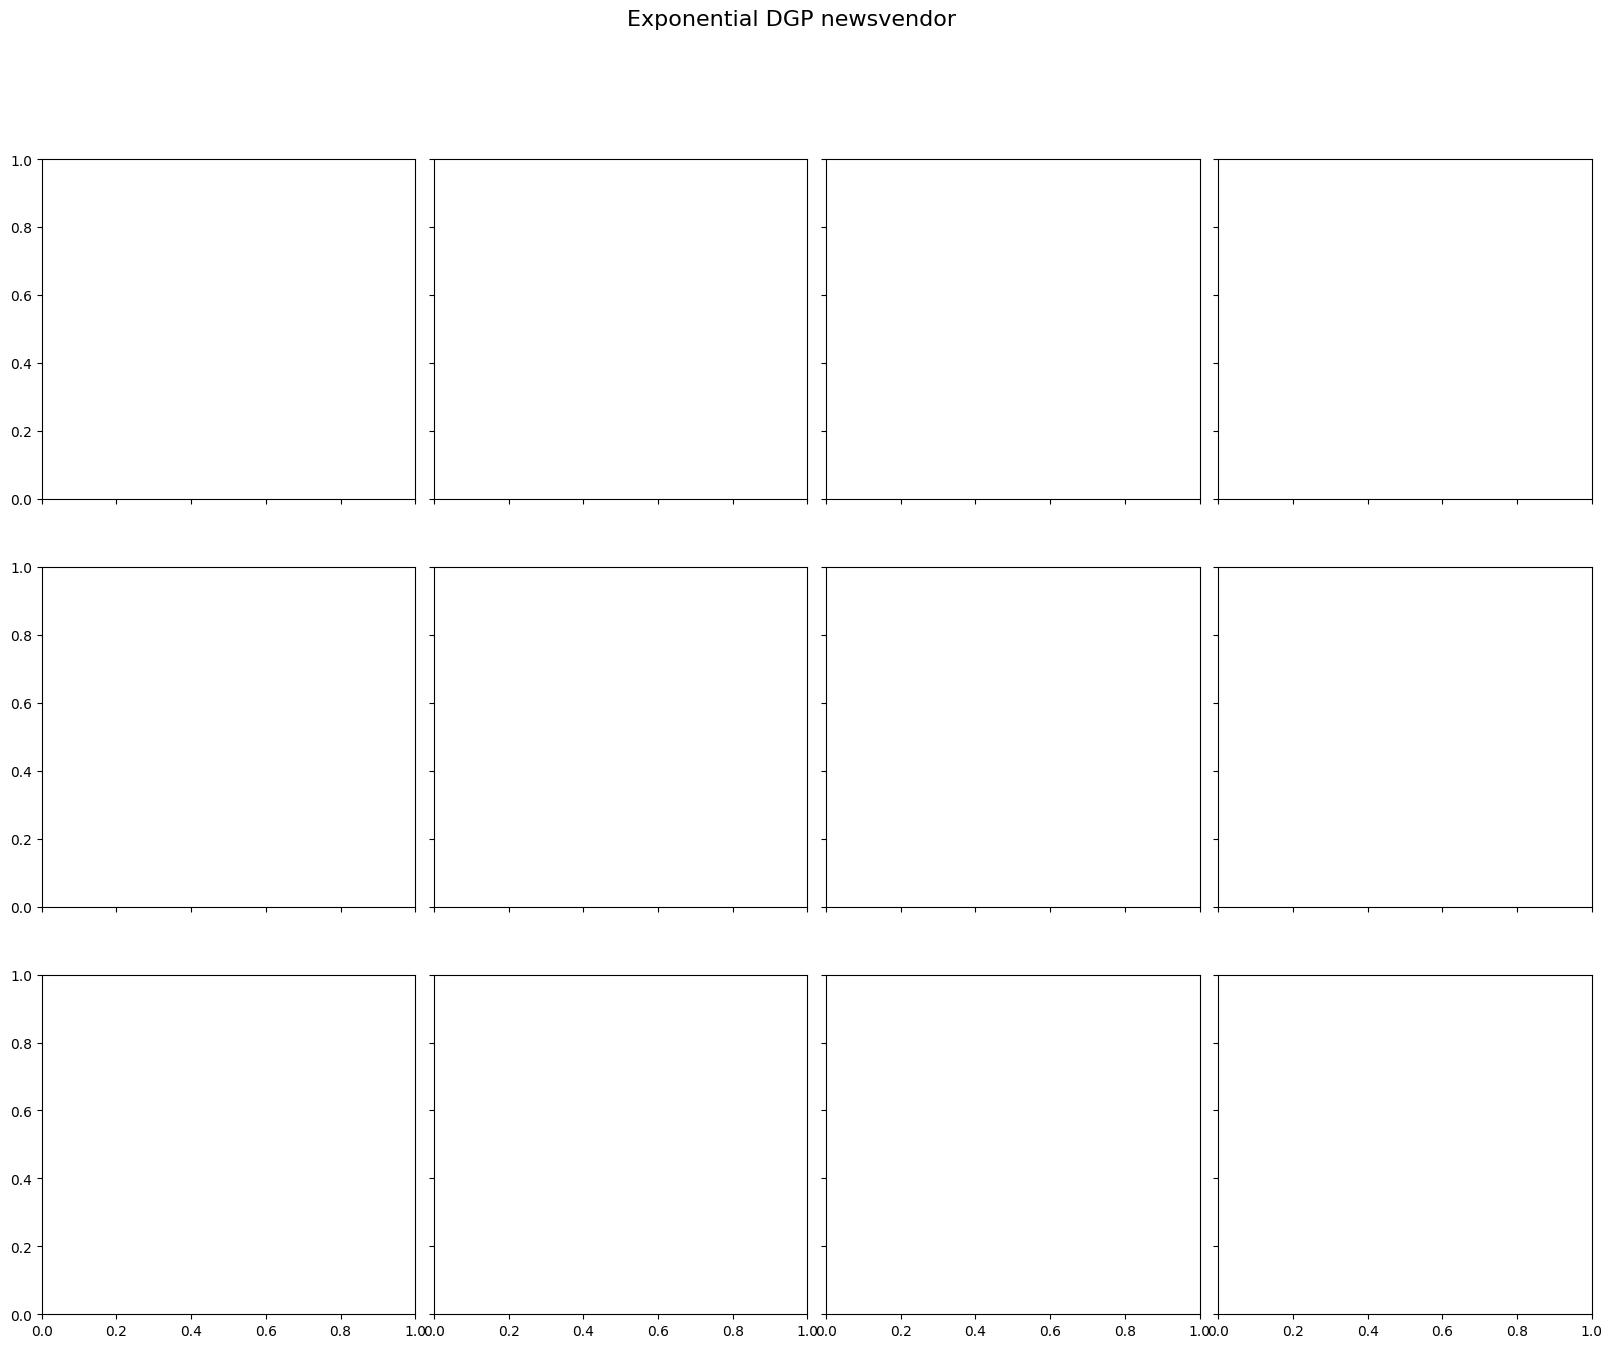

In [8]:
total_samples_list = agg_df.index.get_level_values("num_total_samples").unique().tolist()
dgp_list = agg_df.index.get_level_values("dgp").unique().tolist()

nrows = 3
ncols = len(total_samples_list)
trim_epsilon = 1.0

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, sharex=True, sharey=True, figsize=(5*ncols, nrows*5))
fig.subplots_adjust(wspace=0.05)
pd.options.mode.chained_assignment = None  # default='warn'
fig.suptitle(f"{NiceNameDGP[filter_dgp]} newsvendor", fontsize=16)

nice_var_names = {
    "out_of_sample_var": "Total variance",
    "sum_of_in_group_var": r"$\frac{m-1}{km - 1} \sum^k_{j=1} v_j$",
    "var_of_in_group_mean": r"$\frac{m(k-1)}{km - 1} \text{Var}(\mu_j)$",
}

for i, var_col in enumerate(["out_of_sample_var", "sum_of_in_group_var", "var_of_in_group_mean"]):
    for j, total_samples in enumerate(total_samples_list):
        axis_df = agg_df.loc[:, dgp, :trim_epsilon, total_samples]
        axis_df.loc[:, "is_pareto_front"] = is_minimise_pareto_front(axis_df["out_of_sample_var"].values, axis_df["out_of_sample_mean"].values)
        for algorithm in axis_df.index.get_level_values("algorithm").unique():
            df = axis_df.loc[algorithm, :]
            alpha = 1.0
            is_labelled=True
            mean_variance_plot(axes[i][j], df, **algorithm_inference_style(algorithm, "bayes", label_inference=False), offset=0.0, is_labelled=is_labelled, alpha=alpha, var_col=var_col)
        if j == 0:
            axes[i][j].legend()
            axes[i][j].set_ylabel("Out-of-sample mean")
        axes[i][j].set_title(nice_var_names[var_col] + " for $M$" + f"={total_samples}")
        axes[i][j].set_xlabel("Out-of-sample variance")

# fig.savefig(f"/Users/patrick/Experiments/misdro/paper_bas_figures/{experiment_name}_{filter_dgp}.pdf", bbox_inches="tight")

# Look at the solution

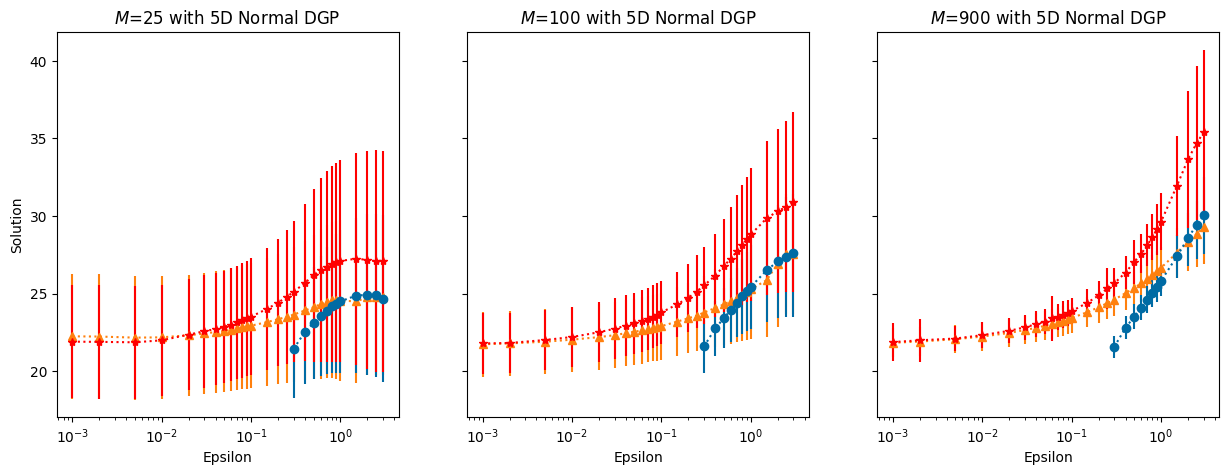

In [ ]:
df = results_df.copy()
df["solution"] = df["solution"].map(lambda x: x[4])
nrows = len(dgp_list)
ncols = len(total_samples_list)
fig, axes = plt.subplots(ncols=ncols, nrows=nrows, sharex=True, sharey=True, figsize=(5*ncols, nrows*5))
solution_df = df.groupby(["algorithm", "dgp", "epsilon", "num_total_samples"]).agg({"solution": ["mean", "std"]})
for i, dgp in enumerate(dgp_list):
    for j, total_samples in enumerate(total_samples_list):
        axis_df = solution_df.loc[:, dgp, :, total_samples]
        for algorithm in axis_df.index.get_level_values("algorithm").unique():
            axes[j].errorbar(axis_df.loc[algorithm, :].index.get_level_values("epsilon"), axis_df.loc[algorithm, :]["solution"]["mean"], yerr=axis_df.loc[algorithm, :]["solution"]["std"], **algorithm_inference_style(algorithm, "bayes"))
        axes[j].set_xscale("log")
        axes[j].set_title("$M$" + f"={total_samples} with {NiceNameDGP[filter_dgp]}")
        axes[j].set_xlabel("Epsilon")
        if j == 0:
            axes[j].set_ylabel("Solution")